In [1]:
# Setup: paths and imports
import sys
from pathlib import Path

import yaml
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / 'src').is_dir() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

SCENARIO_PATH = ROOT / 'scenarios' / 'scenario_base.yaml'
YEARS = 3

In [2]:
# Load scenario and resolve settings paths
with open(SCENARIO_PATH) as f:
    scenario = yaml.safe_load(f)

settings = {
    key: ROOT / scenario[key]
    for key in ['data_registry', 'community', 'farm_profiles', 'water_systems', 'water_policy']
}

print(f"Scenario: {scenario['scenario_name']}")
print(f"Description: {scenario['description']}")
for key, path in settings.items():
    status = 'OK' if path.exists() else 'MISSING'
    print(f"  {key}: {path.name} [{status}]")

Scenario: baseline
Description: Baseline community — research-grade energy data, toy-grade water and building data
  data_registry: data_registry_base.yaml [OK]
  community: community_demands_base.yaml [OK]
  farm_profiles: farm_profile_base.yaml [OK]
  water_systems: water_systems_base.yaml [OK]
  water_policy: water_policy_base.yaml [OK]


In [3]:
# Compute daily water balance from scenario settings
from src.water_balance import compute_daily_water_balance

df = compute_daily_water_balance(
    farm_profiles_path=settings['farm_profiles'],
    water_systems_path=settings['water_systems'],
    water_policy_path=settings['water_policy'],
    community_config_path=settings['community'],
    registry_path=settings['data_registry'],
)

print(f"Computed {len(df)} days")
print(f"Date range: {df['day'].min().date()} to {df['day'].max().date()}")
print(f"Total irrigation demand: {df['irrigation_demand_m3'].sum():,.0f} m\u00b3")
print(f"Total community water:   {df['community_water_demand_m3'].sum():,.0f} m\u00b3")
print(f"Total deficit:           {df['deficit_m3'].sum():,.0f} m\u00b3")
print(f"Total energy:            {df['total_water_energy_kwh'].sum():,.1f} kWh")
print(f"Total cost:              ${df['total_water_cost'].sum():,.2f}")

Computed 5479 days
Date range: 2010-01-01 to 2024-12-31
Total irrigation demand: 1,119,292 m³
Total community water:   154,882 m³
Total deficit:           0 m³
Total energy:            1,700,892.5 kWh
Total cost:              $625,717.37


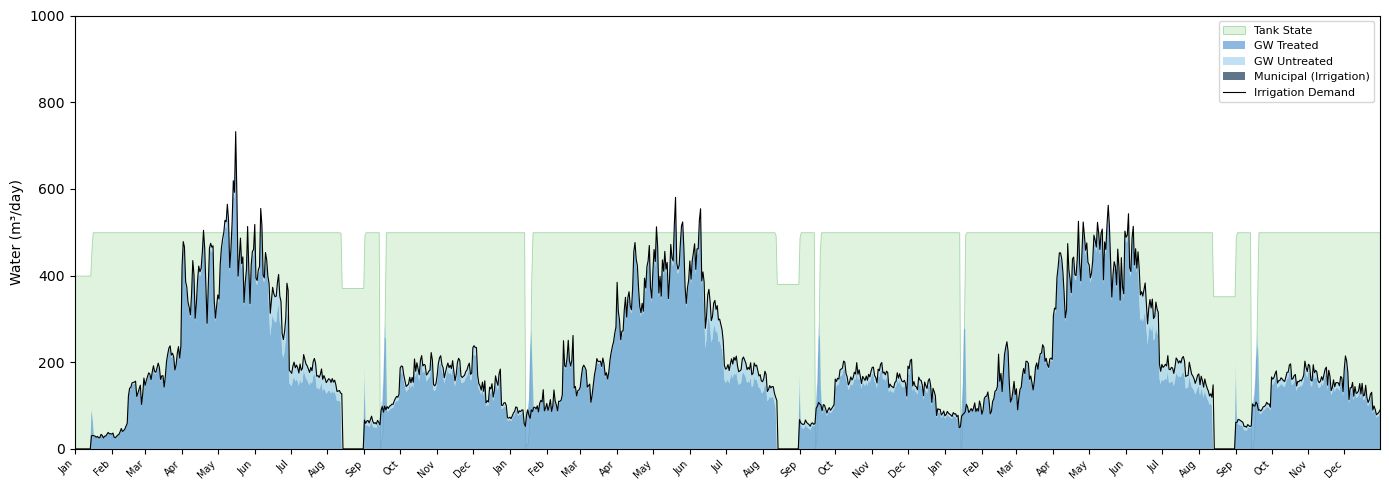

In [4]:
# Water balance: supply (stacked), demand (lines), and tank state
from src.plots import plot_water_balance

fig = plot_water_balance(df, years=YEARS)
plt.show()

/Users/dpbirge/GITHUB/community-agri-pv/src/plots.py:275: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


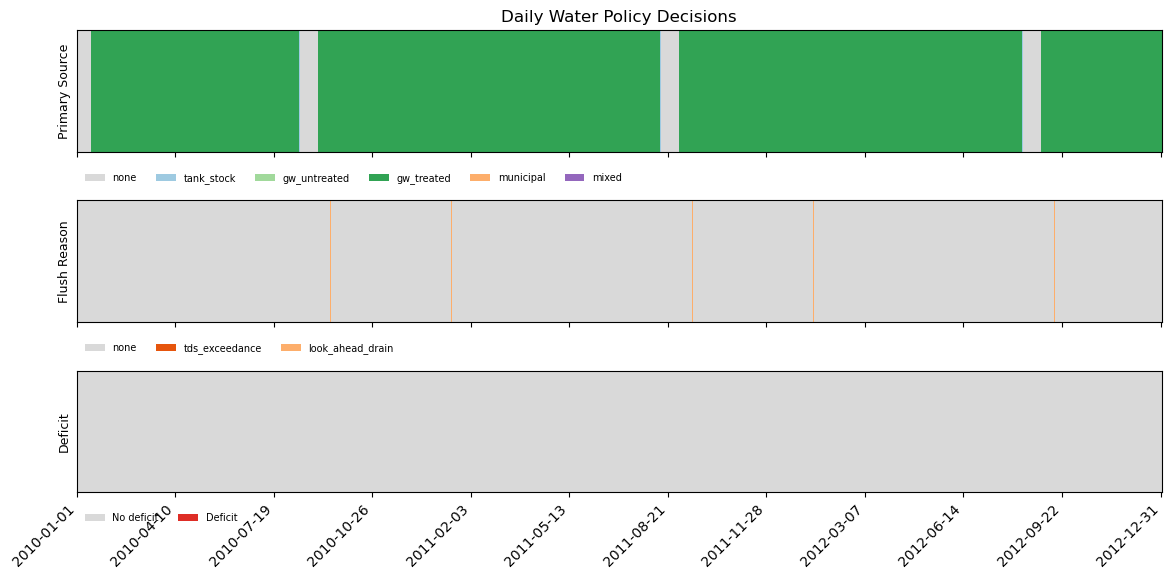

In [5]:
# Policy decisions heatmap (primary source, flush reason, deficit)
from src.plots import plot_water_policy_heatmap

fig = plot_water_policy_heatmap(df, years=YEARS)
plt.show()

In [6]:
# Annual summary statistics
import pandas as pd

annual = df.groupby(df['day'].dt.year).agg(
    irrigation_demand_m3=('irrigation_demand_m3', 'sum'),
    community_water_m3=('community_water_demand_m3', 'sum'),
    total_delivered_m3=('irrigation_delivered_m3', 'sum'),
    deficit_m3=('deficit_m3', 'sum'),
    gw_untreated_m3=('gw_untreated_to_tank_m3', 'sum'),
    gw_treated_m3=('gw_treated_to_tank_m3', 'sum'),
    municipal_irrig_m3=('municipal_to_tank_m3', 'sum'),
    total_water_energy_kwh=('total_water_energy_kwh', 'sum'),
    total_cost_usd=('total_water_cost', 'sum'),
).round(1)

annual.index.name = 'year'
annual

,irrigation_demand_m3,community_water_m3,total_delivered_m3,deficit_m3,gw_untreated_m3,gw_treated_m3,municipal_irrig_m3,total_water_energy_kwh,total_cost_usd
year,,,,,,,,,
2010,72301.8,10330.4,72801.8,0.0,5026.6,67875.2,0.0,109050.5,40355.3
2011,72424.4,10292.8,73424.4,0.0,4985.5,68438.9,0.0,110134.4,40657.8
2012,74119.2,10402.1,75119.2,0.0,5084.0,70035.3,0.0,112691.7,41521.4
2013,75194.1,10476.8,76194.1,0.0,5018.3,71175.9,0.0,114445.0,42150.6
2014,74860.3,10380.1,75860.3,0.0,5117.6,70742.7,0.0,113824.5,41860.6
2015,73759.8,10323.7,74759.8,0.0,5011.8,69748.1,0.0,112197.8,41353.0
2016,75538.4,10485.4,76538.4,0.0,5156.7,71381.8,0.0,114840.0,42250.7
2017,75454.3,10443.2,76454.3,0.0,5173.5,71280.9,0.0,114688.2,42186.3
2018,74247.5,10354.6,75247.5,0.0,5017.9,70229.6,0.0,112958.4,41598.4
